In [34]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor


from scipy.fft import fft, fftfreq
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load datasets
path = '../dataset/'
train_path = os.path.join(path, 'Train.csv')
test_path = os.path.join(path, 'Test.csv')
gap_train_path = os.path.join(path, 'Gap_Train.csv')
gap_test_path = os.path.join(path, 'Gap_Test.csv')
sample_submission_path = os.path.join(path, 'SampleSubmission.csv')

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
train_gap_df = pd.read_csv(gap_train_path)
test_gap_df = pd.read_csv(gap_test_path)
sample_submission = pd.read_csv(sample_submission_path)

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7744 entries, 0 to 7743
Data columns (total 44 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site         7744 non-null   object 
 1   PID          7744 non-null   object 
 2   lon          7744 non-null   float64
 3   lat          7744 non-null   float64
 4   pH           7744 non-null   float64
 5   alb          7744 non-null   int64  
 6   bio1         7744 non-null   int64  
 7   bio12        7744 non-null   int64  
 8   bio15        7744 non-null   int64  
 9   bio7         7744 non-null   int64  
 10  bp           7744 non-null   float64
 11  cec20        7744 non-null   float64
 12  dows         7744 non-null   float64
 13  ecec20       7739 non-null   float64
 14  hp20         7739 non-null   float64
 15  ls           7744 non-null   float64
 16  lstd         7744 non-null   float64
 17  lstn         7744 non-null   float64
 18  mb1          7744 non-null   float64
 19  mb2   

In [4]:
missing_values = [col for col in train_df.columns if train_df[col].isnull().any()]
print(f"Missing values in train_df: {missing_values}")

Missing values in train_df: ['ecec20', 'hp20', 'xhp20', 'BulkDensity']


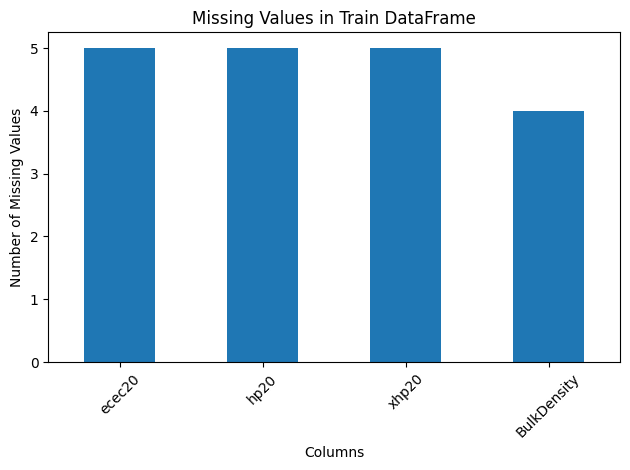

Data types of missing values:
ecec20         float64
hp20           float64
xhp20          float64
BulkDensity    float64
dtype: object
Missing values after imputation: []


In [5]:
if missing_values:
    train_df[missing_values].isnull().sum().sort_values(ascending=False).plot(kind='bar')
    plt.title('Missing Values in Train DataFrame')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # To check the data types of the missing values 
    missing_data_types = train_df[missing_values].dtypes
    print("Data types of missing values:")
    print(missing_data_types)

    # Imputing missing values
    for col in missing_values:
        train_df[col].fillna(train_df[col].mean(), inplace=True)

    missing_values_after = [col for col in train_df.columns if train_df[col].isnull().any()]
    print(f"Missing values after imputation: {missing_values_after}")
else:
    print("No missing values found in training data")

The test set has no mising values

### EDA

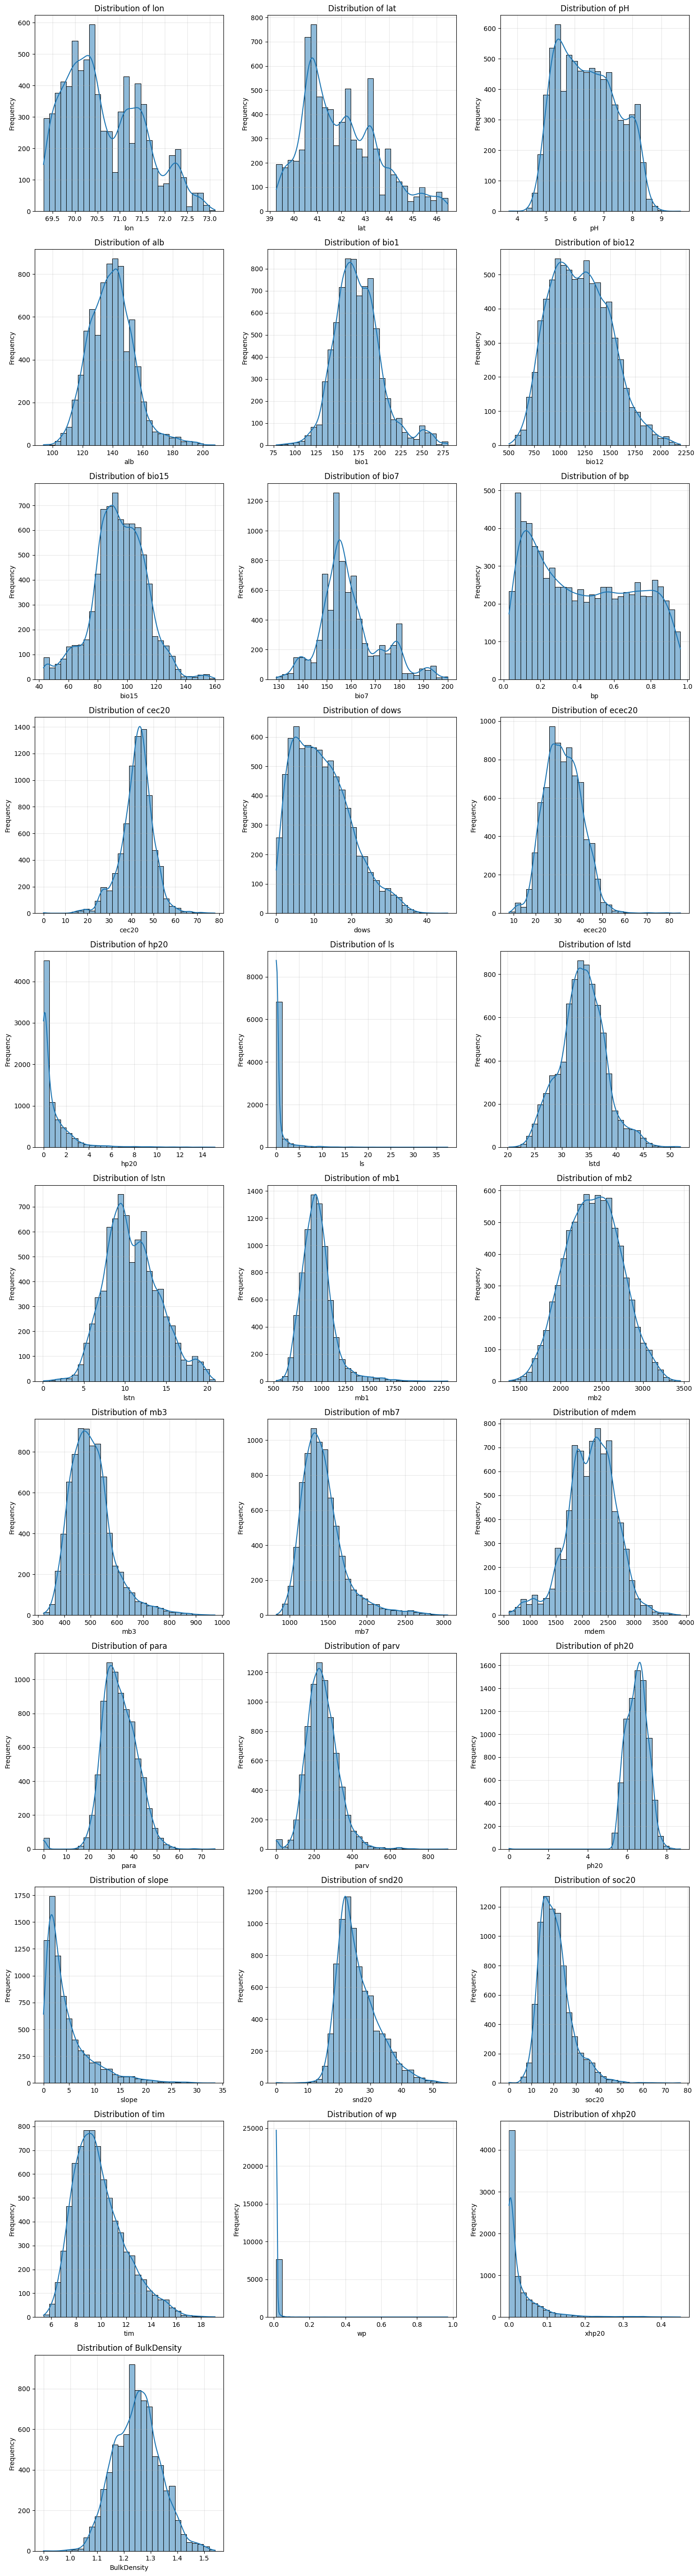

In [6]:
import math
# Plot the distribution of numerical features without the target variables
def plot_numerical_feature_distributions(dataframe, numerical_features, target_variables, n_cols=3):
    """
    Plots the distribution of numerical features excluding target variables.

    Parameters:
    - dataframe: pandas DataFrame containing the data.
    - numerical_features: List of numerical feature column names.
    - target_variables: List of target variable column names to exclude.
    - n_cols: Number of columns in the subplot grid (default is 3).
    """
    num_features = [col for col in numerical_features if col not in target_variables]
    n_features = len(num_features)
    n_rows = math.ceil(n_features / n_cols)

    plt.figure(figsize=(15, 5 * n_rows))

    for i, feature in enumerate(num_features, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(dataframe[feature], kde=True, bins=30)
        plt.title(f'Distribution of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


numerical_features = [col for col in train_df.columns if train_df[col].dtype in ['int64', 'float64']]
target_variables = ['N', 'P', 'K', 'Zn', 'S', 'Ca', 'Mg', 'B', 'Cu', 'Fe', 'Mn']
plot_numerical_feature_distributions(train_df, numerical_features, target_variables, n_cols=3)

### Insights 
- Most of the variables are positively skewed but since we are going to be using tree based algorithms 

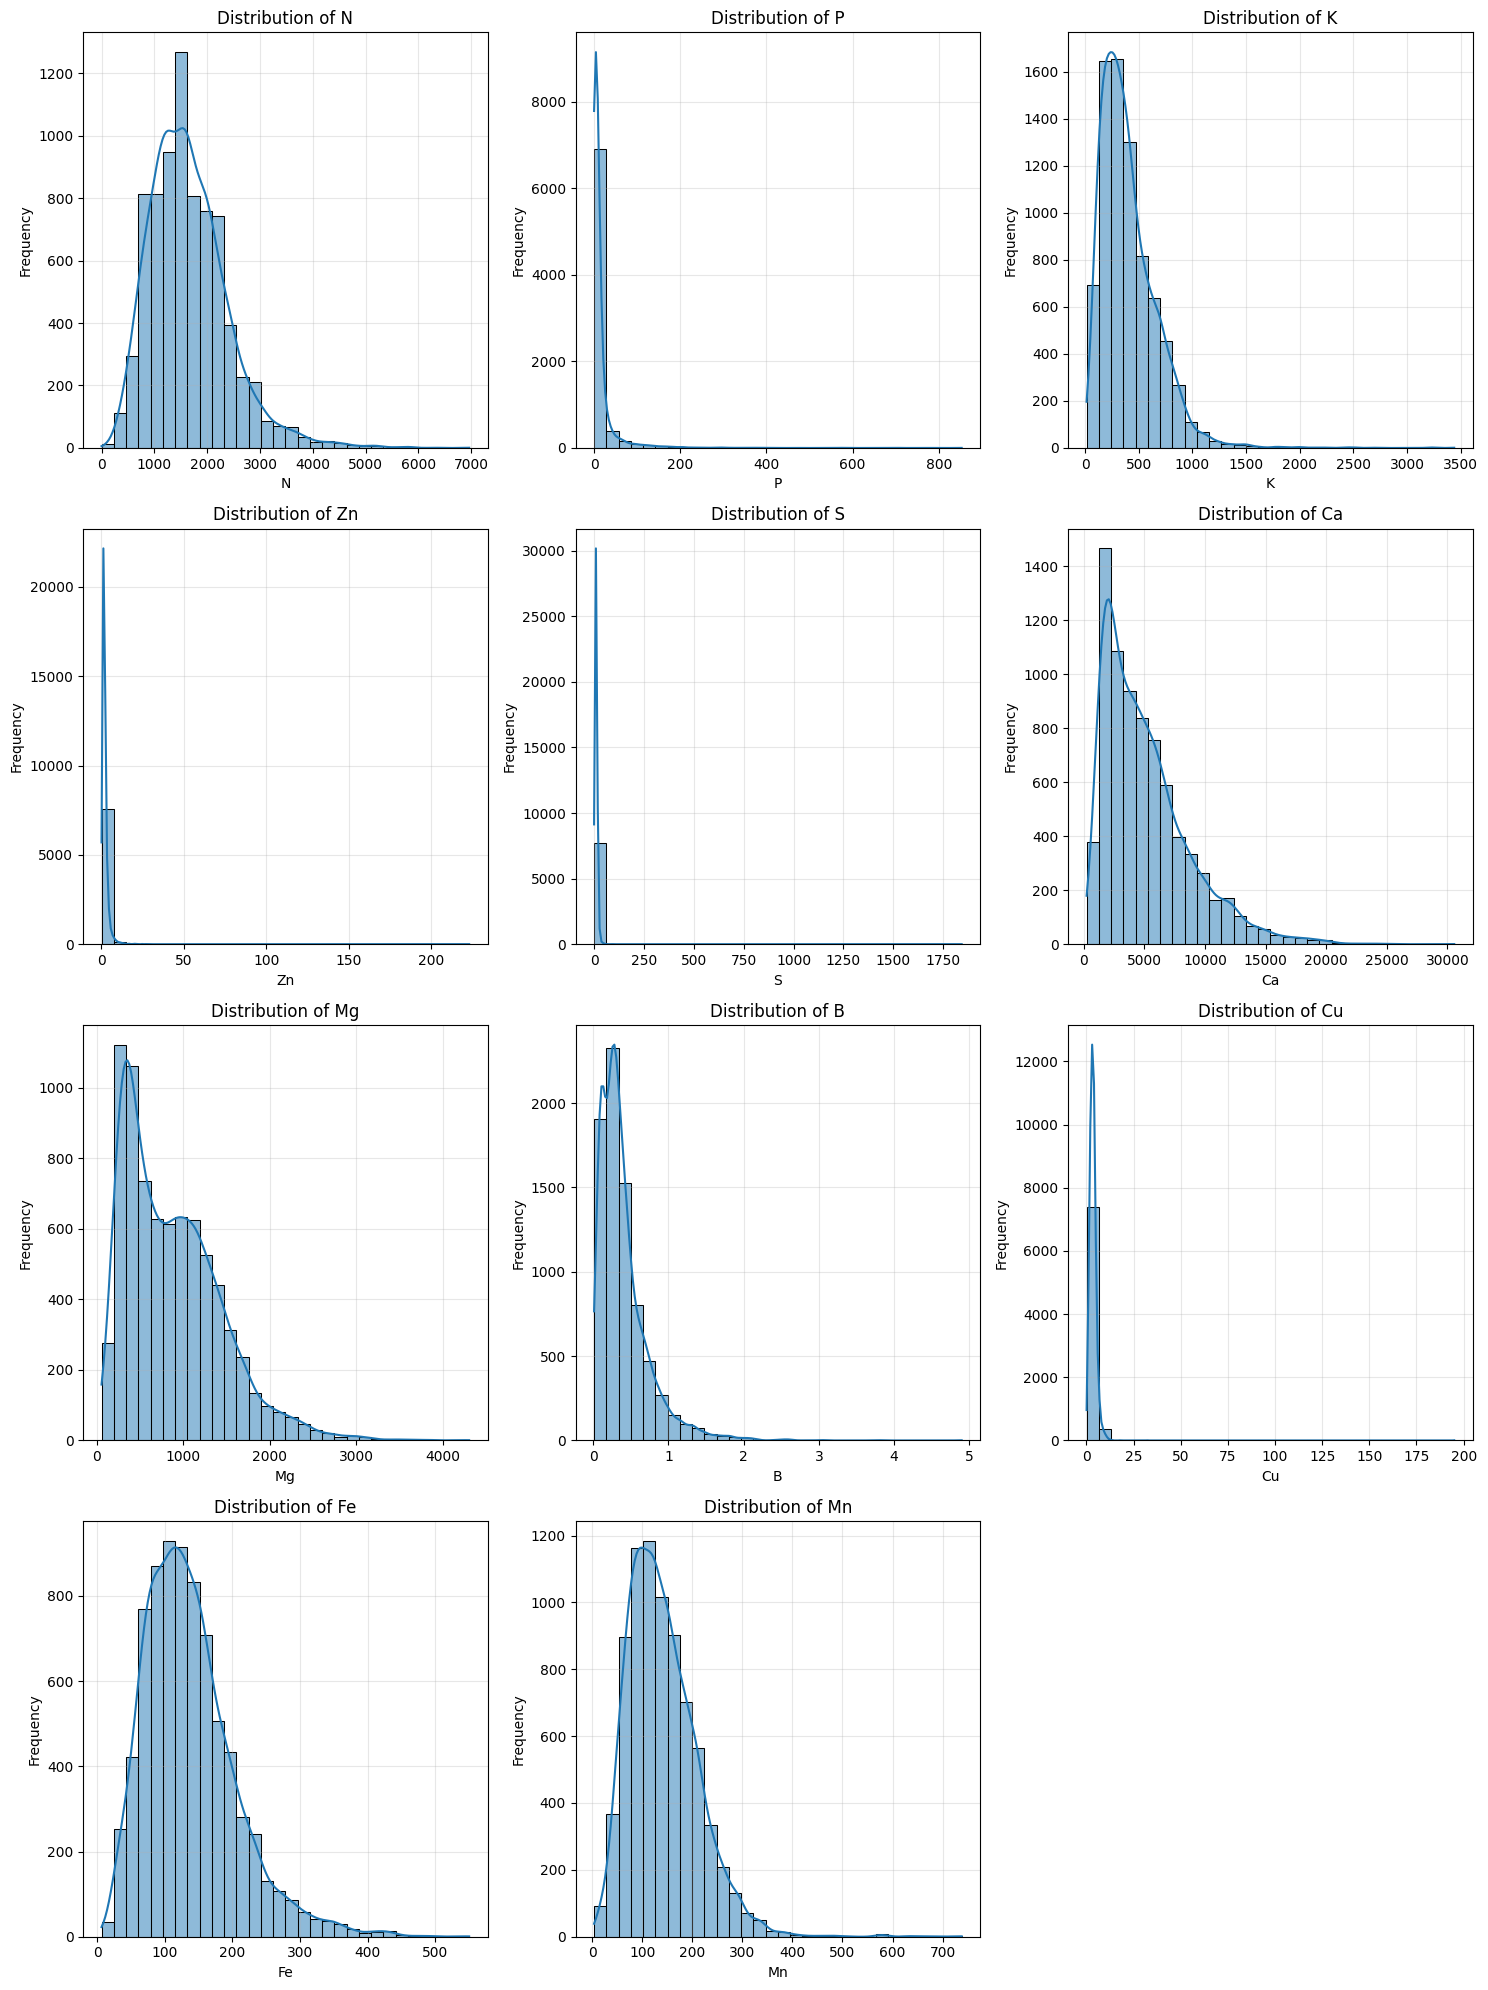

In [7]:
# Plot the distribution of target variables
def plot_target_variable_distributions(dataframe, target_variables, n_cols=3):
    """
    Plots the distribution of target variables.
    """
    n_targets = len(target_variables)
    n_rows = math.ceil(n_targets / n_cols)

    plt.figure(figsize=(15, 5 * n_rows))

    for i, target in enumerate(target_variables, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(dataframe[target], kde=True, bins=30)
        plt.title(f'Distribution of {target}')
        plt.xlabel(target)
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_target_variable_distributions(train_df, target_variables, n_cols=3)


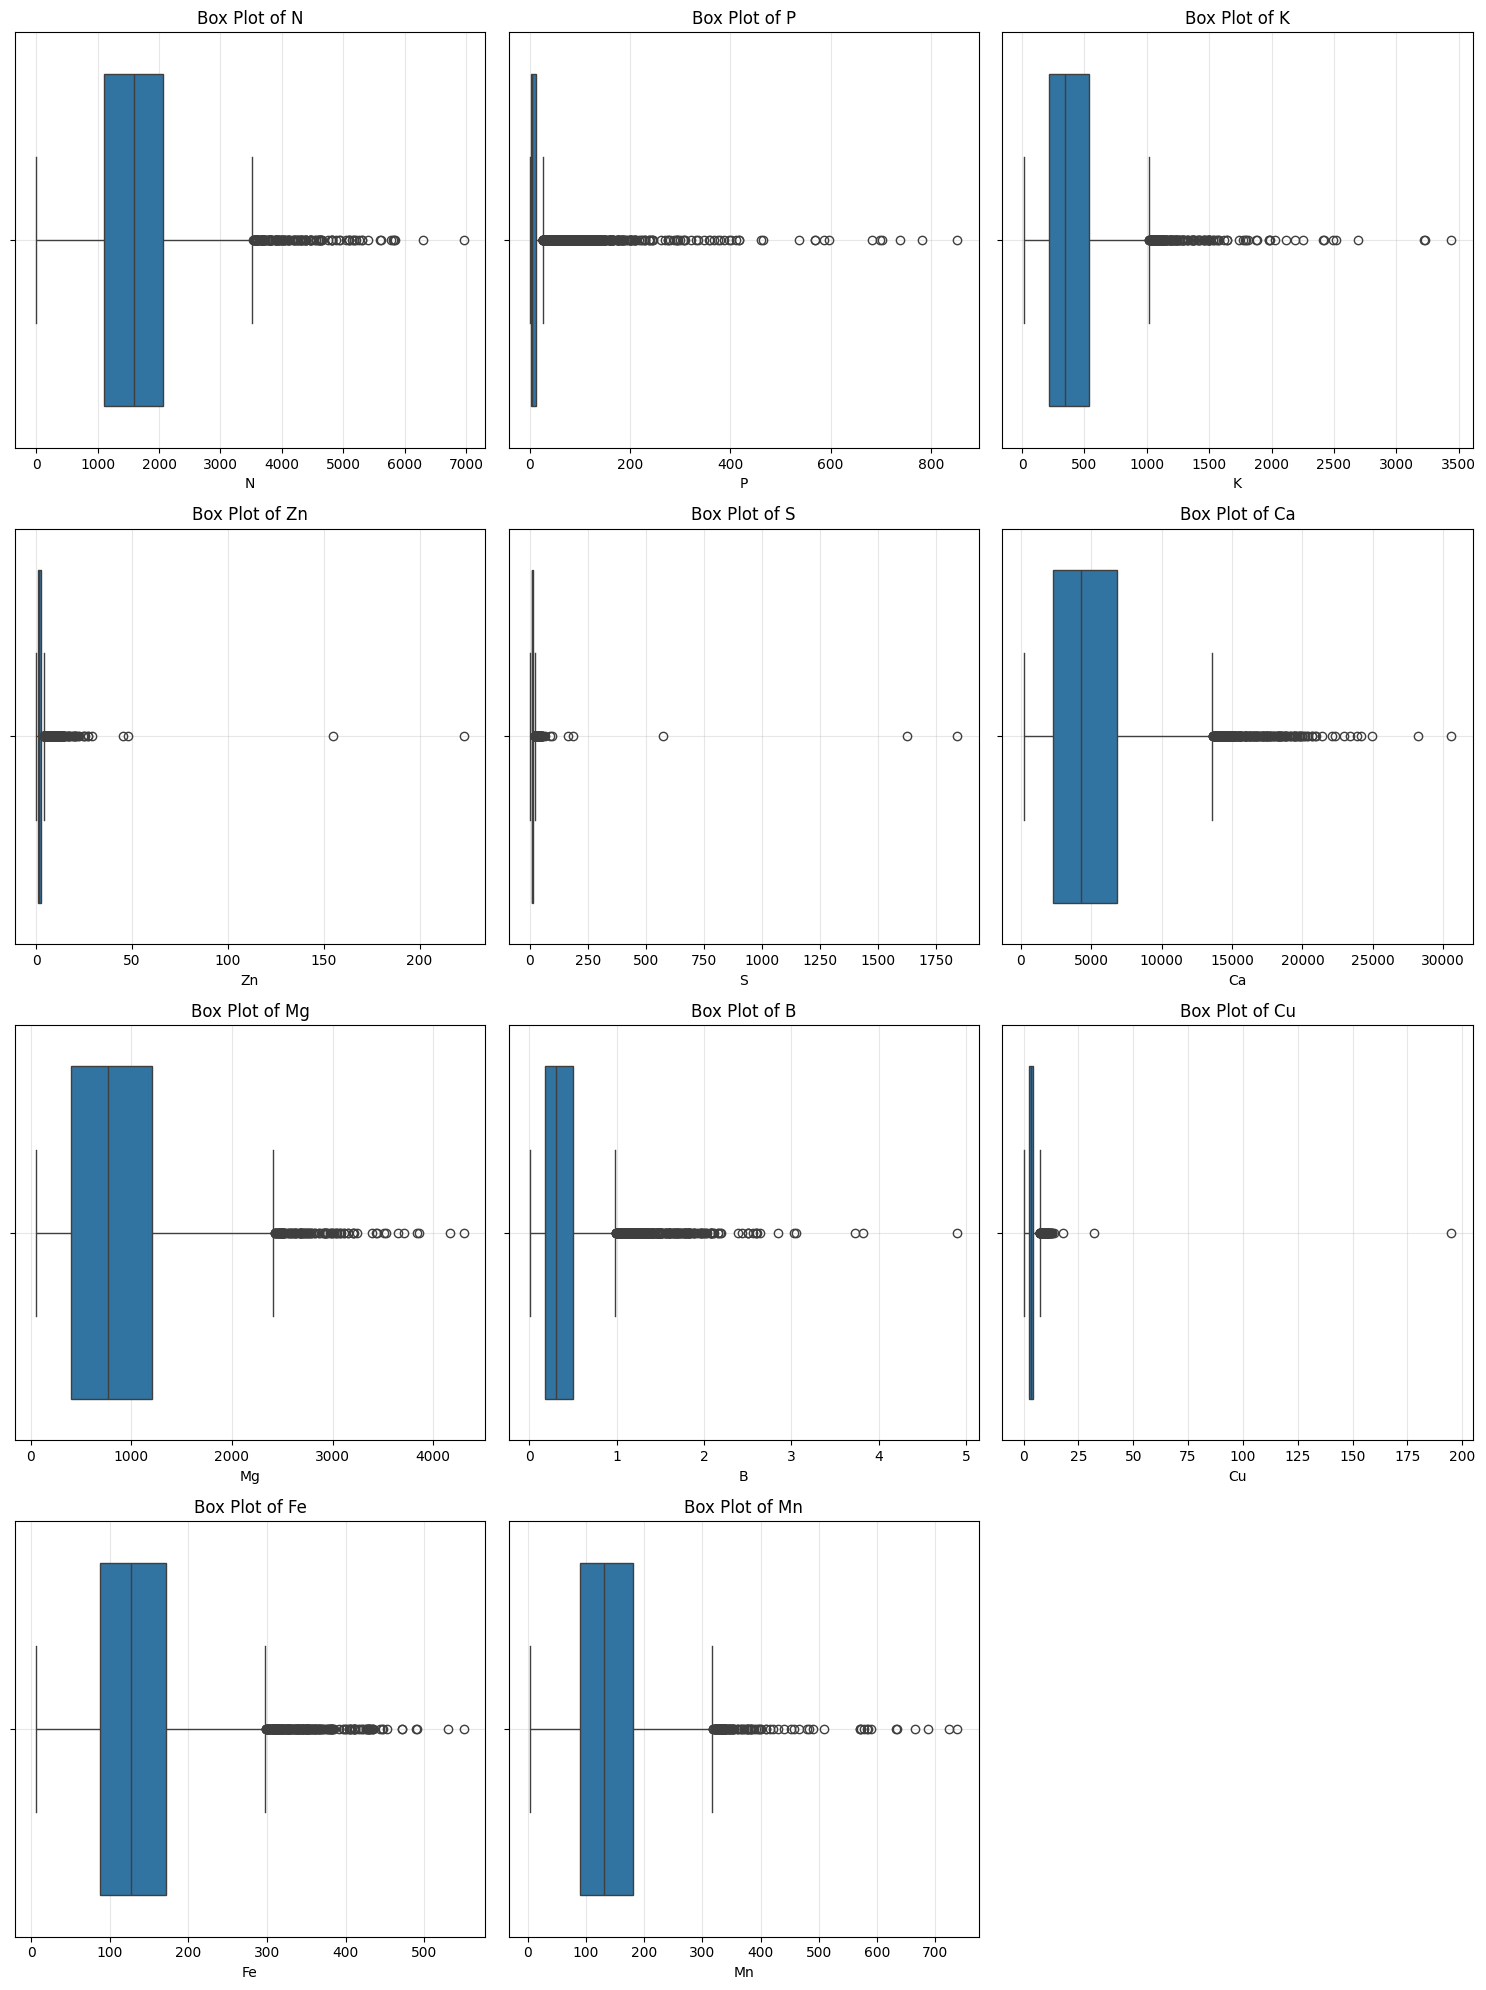

In [8]:
# Plot the box plots for target variables
def plot_target_variable_boxplots(dataframe, target_variables, n_cols=3):
    """
    Plots the box plots for target variables.
    """
    n_targets = len(target_variables)
    n_rows = math.ceil(n_targets / n_cols)

    plt.figure(figsize=(15, 5 * n_rows))

    for i, target in enumerate(target_variables, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.boxplot(x=dataframe[target])
        plt.title(f'Box Plot of {target}')
        plt.xlabel(target)
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_target_variable_boxplots(train_df, target_variables, n_cols=3)

### Insights 
- There is a strong presence of outliers

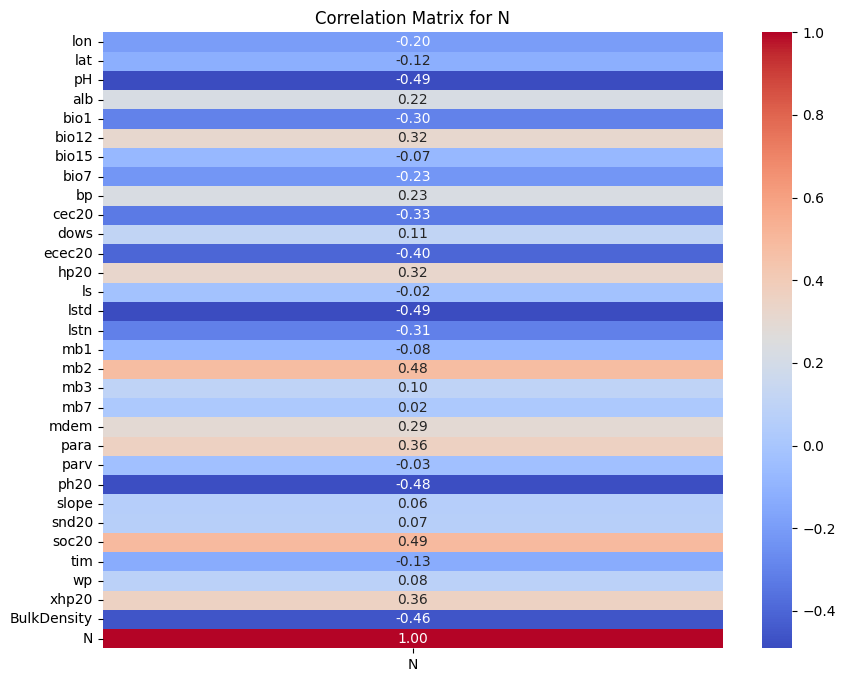

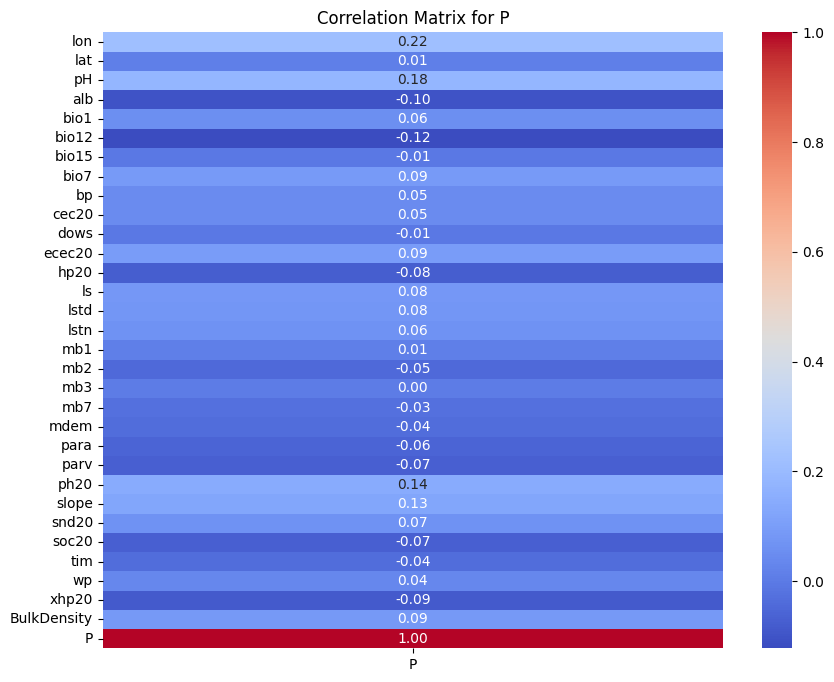

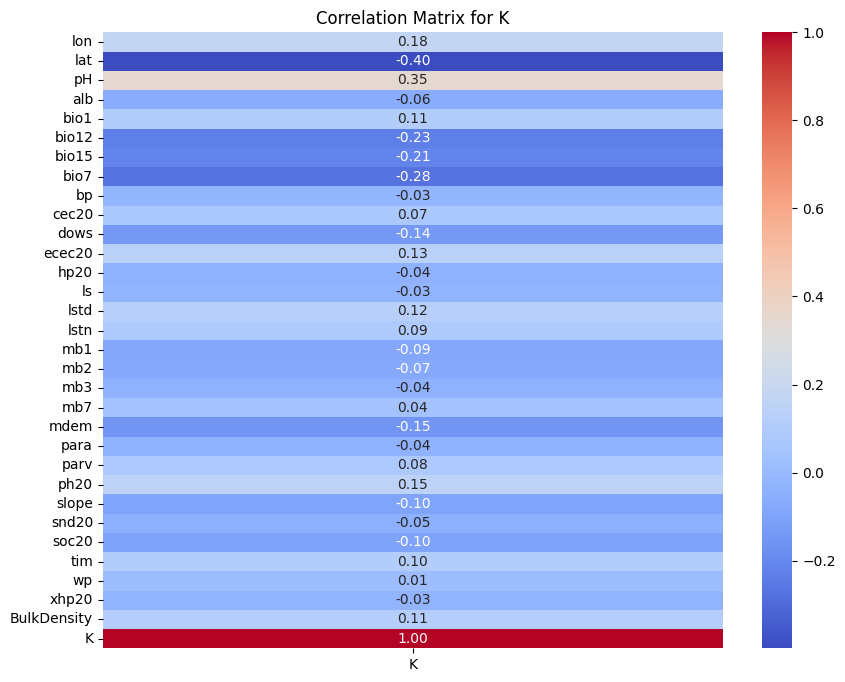

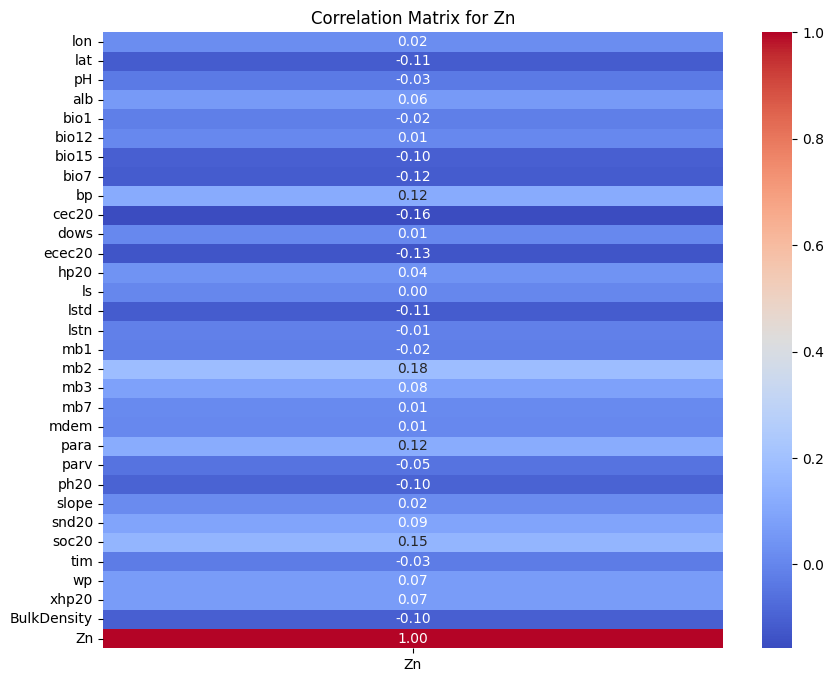

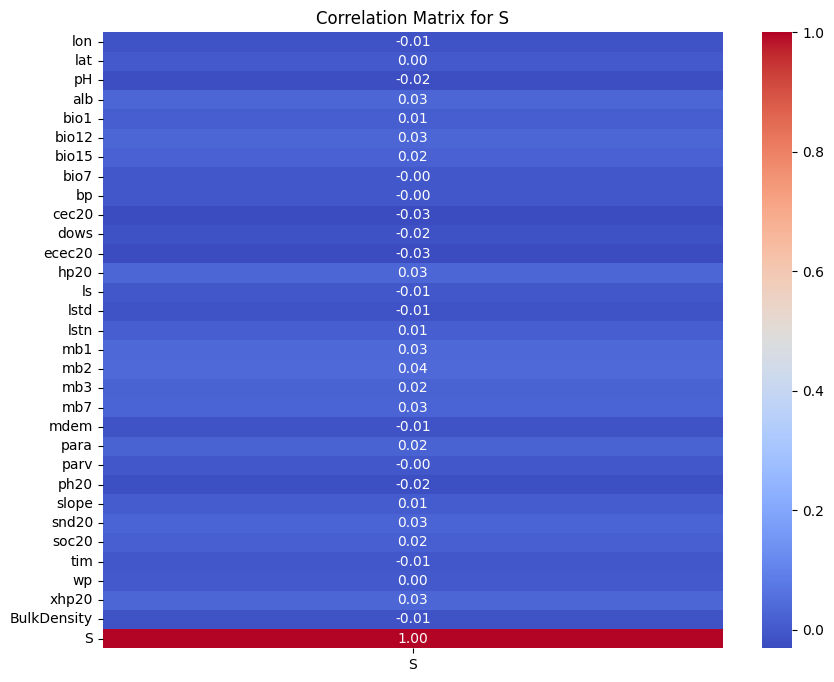

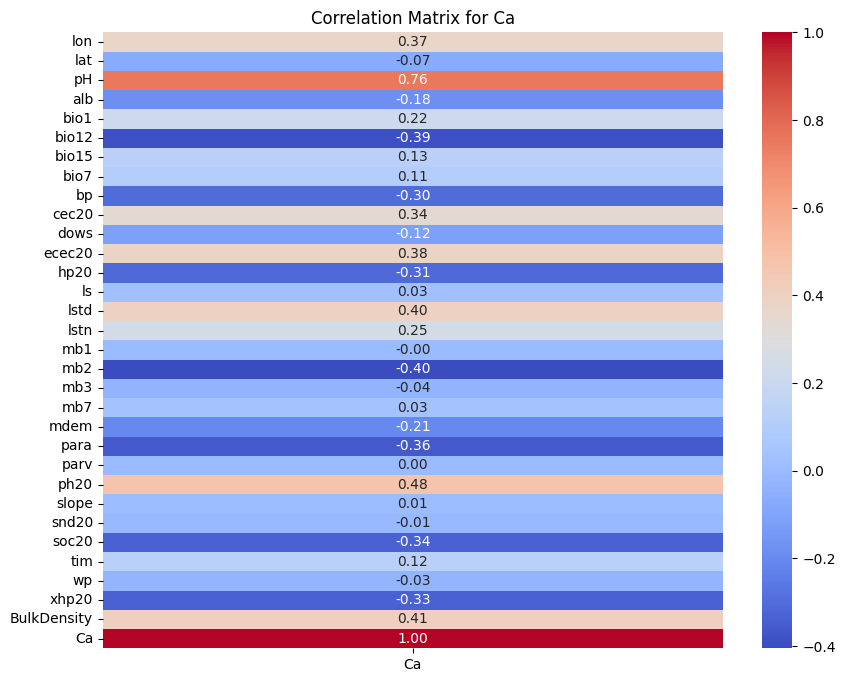

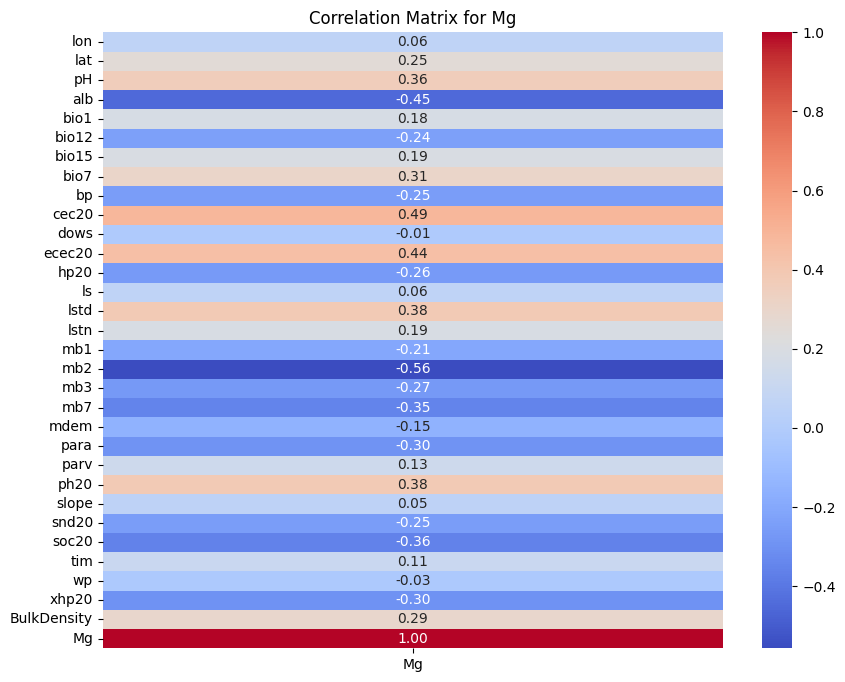

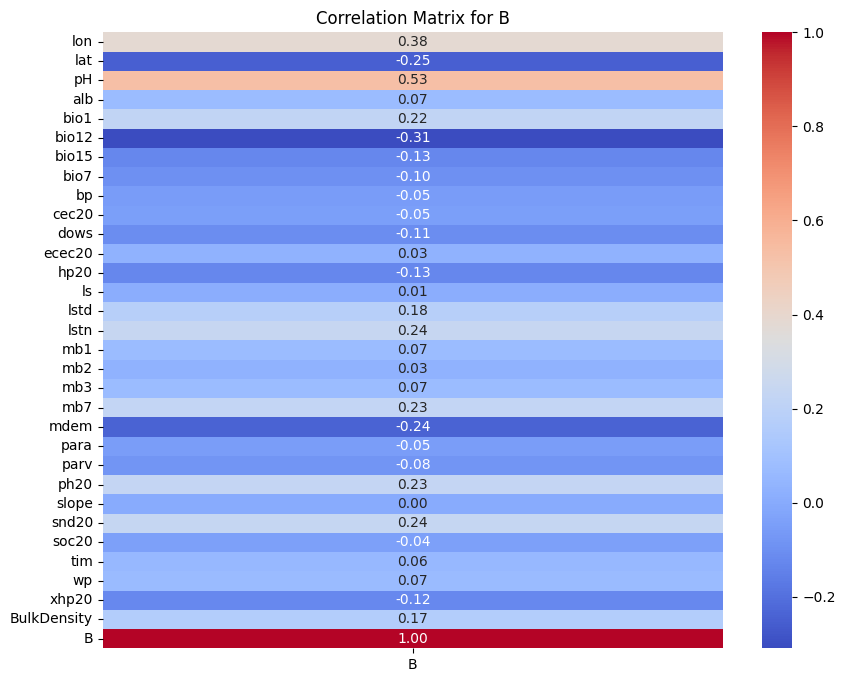

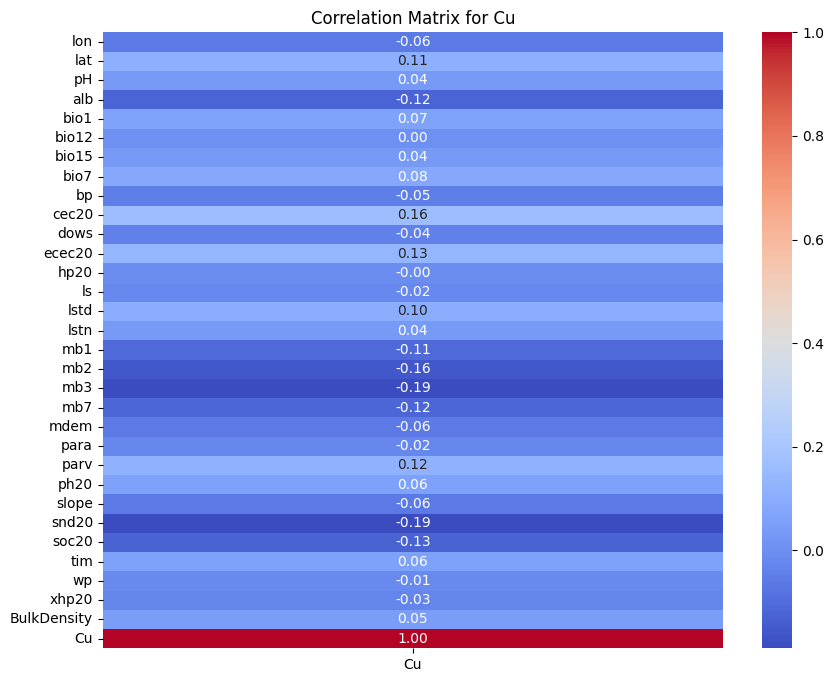

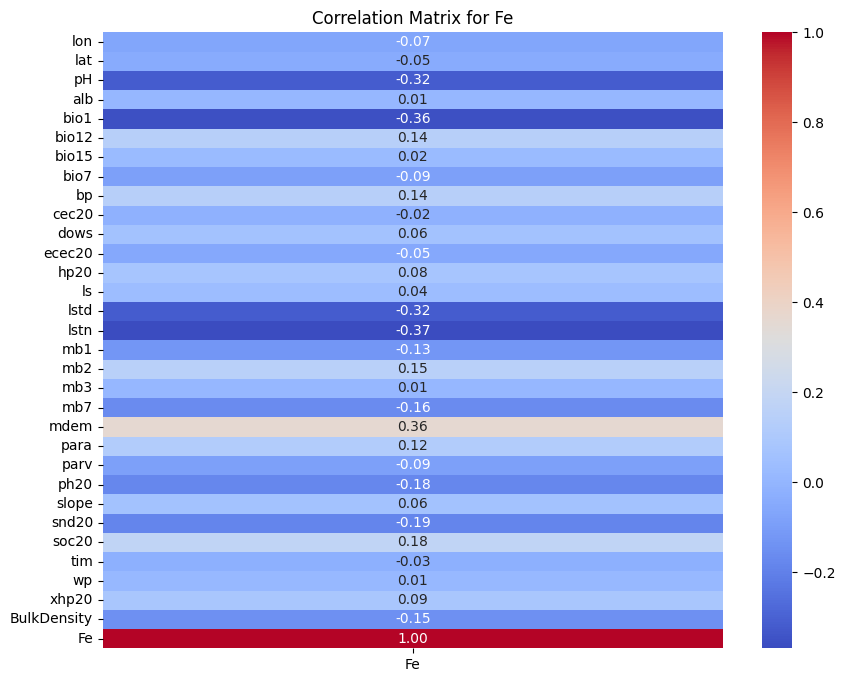

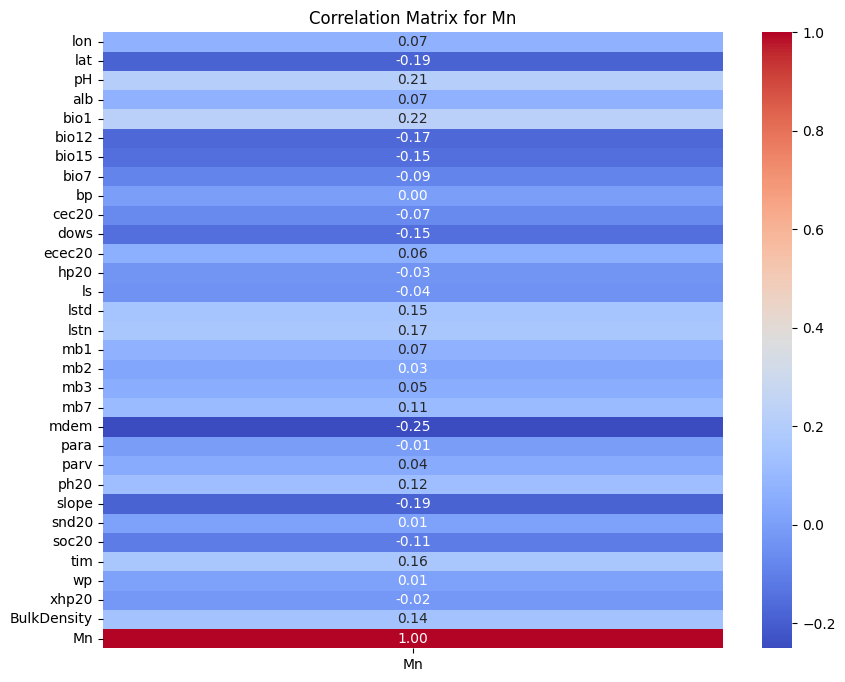

In [9]:
# Correlation matrix for each target variable 
def plot_correlation_matrix(dataframe, numerical_columns, target_variable, target_variables):
    """
    Plots the correlation matrix for numerical columns excluding target-to-target correlations.
    """
    num_columns_excluding_targets = [col for col in numerical_columns if col not in target_variables]
    corr_matrix = dataframe[num_columns_excluding_targets + [target_variable]].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix[[target_variable]], annot=True, cmap='coolwarm', fmt='.2f')
    plt.title(f'Correlation Matrix for {target_variable}')
    plt.show()

for target in target_variables:
    if target in train_df.columns:
        plot_correlation_matrix(train_df, numerical_features, target, target_variables)


In [10]:
def top_correlated_features(dataframe, target_variable, n=5):
    """
    Returns the top n numerical features correlated with the target variable.
    """
    numerical_columns = dataframe.select_dtypes(include=['number']).columns
    corr = dataframe[numerical_columns].corr()[target_variable].abs().sort_values(ascending=False)
    top_features = corr.index[1:n+1].tolist()
    top_values = corr.iloc[1:n+1].tolist()
    return list(zip(top_features, top_values))

for target in target_variables:
    if target in train_df.columns:
        top_features_with_values = top_correlated_features(train_df, target)
        print(f"Top {len(top_features_with_values)} numerical features correlated with {target}:")
        for feature, value in top_features_with_values:
            print(f"  {feature}: {value:.4f}")
        print()



Top 5 numerical features correlated with N:
  pH: 0.4905
  lstd: 0.4884
  soc20: 0.4881
  ph20: 0.4799
  mb2: 0.4773

Top 5 numerical features correlated with P:
  K: 0.4076
  B: 0.2974
  lon: 0.2187
  Zn: 0.2092
  pH: 0.1826

Top 5 numerical features correlated with K:
  B: 0.5812
  P: 0.4076
  lat: 0.3989
  pH: 0.3452
  Ca: 0.3408

Top 5 numerical features correlated with Zn:
  P: 0.2092
  mb2: 0.1822
  N: 0.1660
  cec20: 0.1574
  soc20: 0.1532

Top 5 numerical features correlated with S:
  Cu: 0.0794
  Mg: 0.0703
  B: 0.0667
  mb2: 0.0414
  N: 0.0412

Top 5 numerical features correlated with Ca:
  pH: 0.7570
  B: 0.5350
  ph20: 0.4754
  BulkDensity: 0.4119
  mb2: 0.4049

Top 5 numerical features correlated with Mg:
  mb2: 0.5569
  cec20: 0.4859
  alb: 0.4497
  ecec20: 0.4430
  N: 0.4086

Top 5 numerical features correlated with B:
  K: 0.5812
  Ca: 0.5350
  pH: 0.5324
  lon: 0.3845
  Fe: 0.3129

Top 5 numerical features correlated with Cu:
  Mg: 0.1890
  mb3: 0.1887
  snd20: 0.1881


In [11]:
# VIF Analysis
X_cols = [col for col in numerical_features if col not in target_variables]
X = train_df[X_cols]

# Create VIF dataframe
vif = pd.DataFrame()
vif["features"] = X.columns

# Calculate VIF for all variables
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("VIF Analysis:")
print(vif.sort_values('VIF Factor', ascending=False))


VIF Analysis:
       features    VIF Factor
0           lon  10406.840426
1           lat   5884.614546
4          bio1   4843.900185
20         mdem   2939.200160
7          bio7   1451.093817
30  BulkDensity    689.478381
3           alb    655.142351
14         lstd    563.685934
23         ph20    545.420950
17          mb2    417.356261
16          mb1    355.255381
19          mb7    226.642921
18          mb3    217.073914
15         lstn    191.135333
9         cec20    161.743126
2            pH    121.433584
21         para     70.672805
25        snd20     67.364664
6         bio15     65.301908
29        xhp20     56.041112
11       ecec20     53.612224
12         hp20     52.183881
27          tim     48.985412
5         bio12     46.795900
26        soc20     30.151110
22         parv     14.555440
8            bp      6.614898
24        slope      4.721720
10         dows      4.362176
28           wp      2.035584
13           ls      1.458535


### Insights 
- Removing values with a very high VIF (>10)
    - mdem, lon, lat

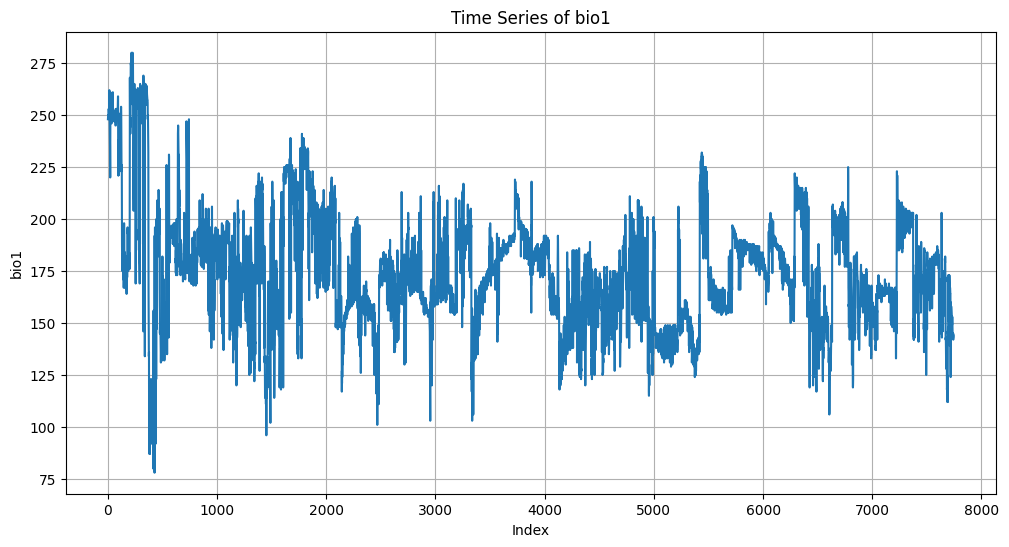

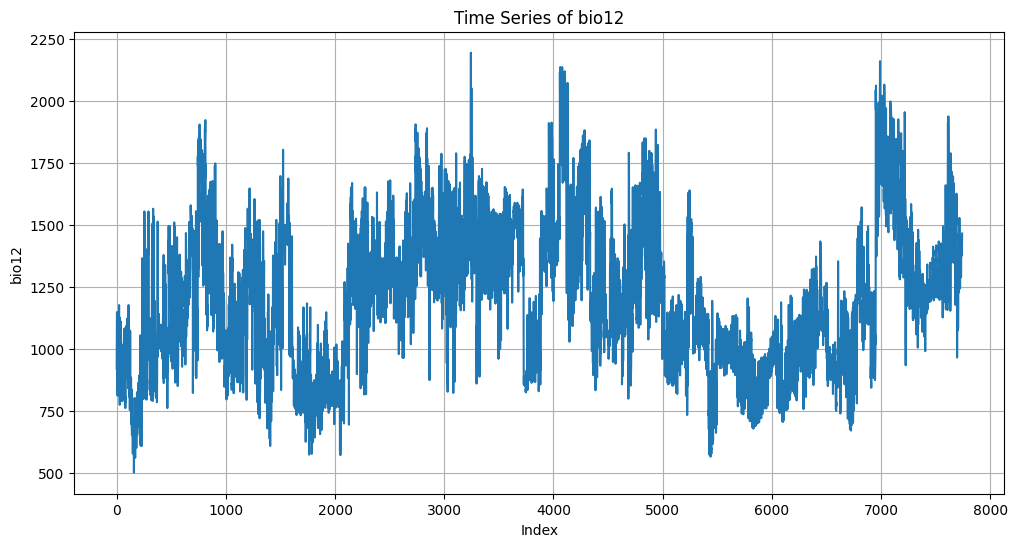

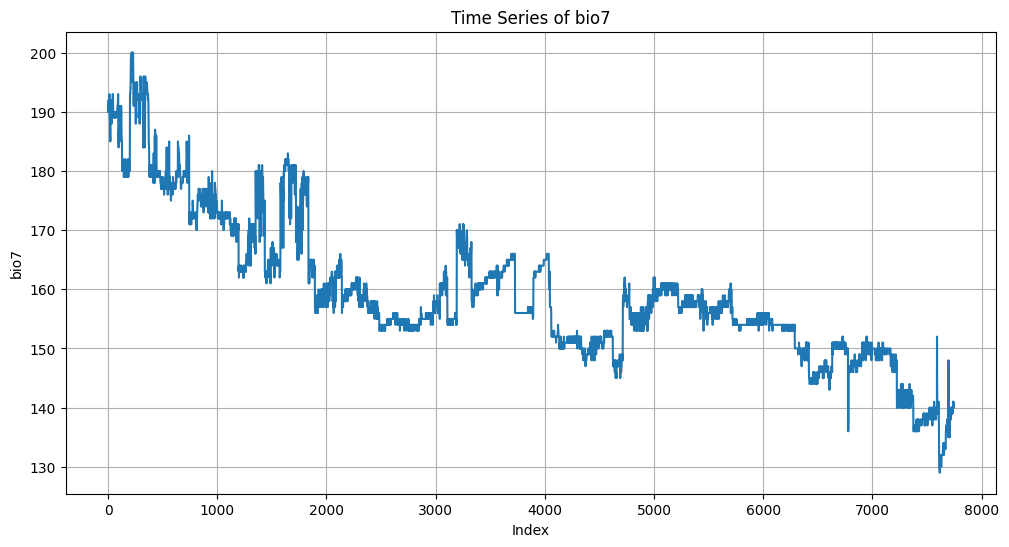

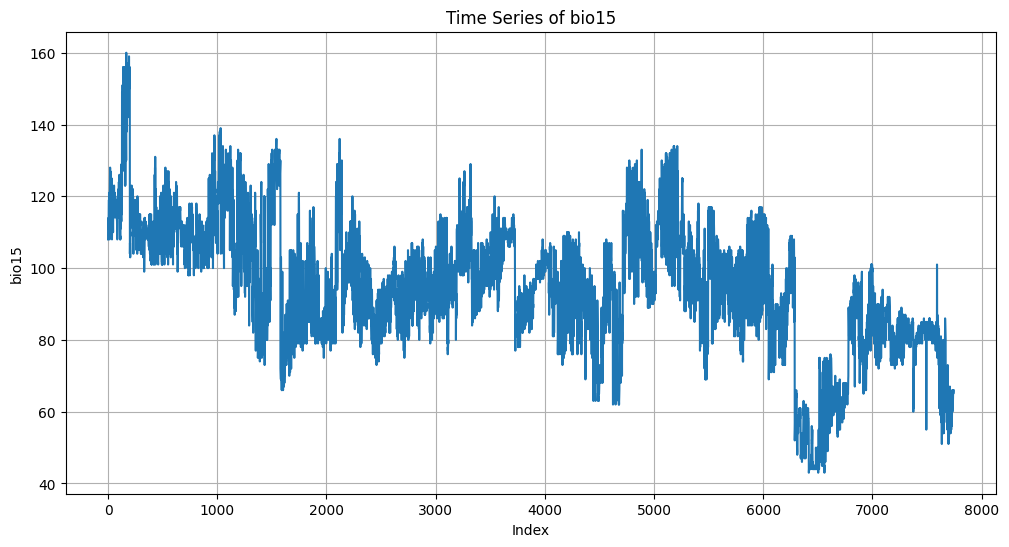

In [12]:
# Plot time series function
def plot_time_series(dataframe, feature, title):
    """
    Plots the time series of a given feature.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(dataframe.index, dataframe[feature])
    plt.title(title)
    plt.xlabel('Index')
    plt.ylabel(feature)
    plt.grid(True)
    plt.show()

# Check if bio features exist before plotting
bio_features = ['bio1', 'bio12', 'bio7', 'bio15']
existing_bio_features = [f for f in bio_features if f in train_df.columns]

for feature in existing_bio_features:
    plot_time_series(train_df, feature, f'Time Series of {feature}')


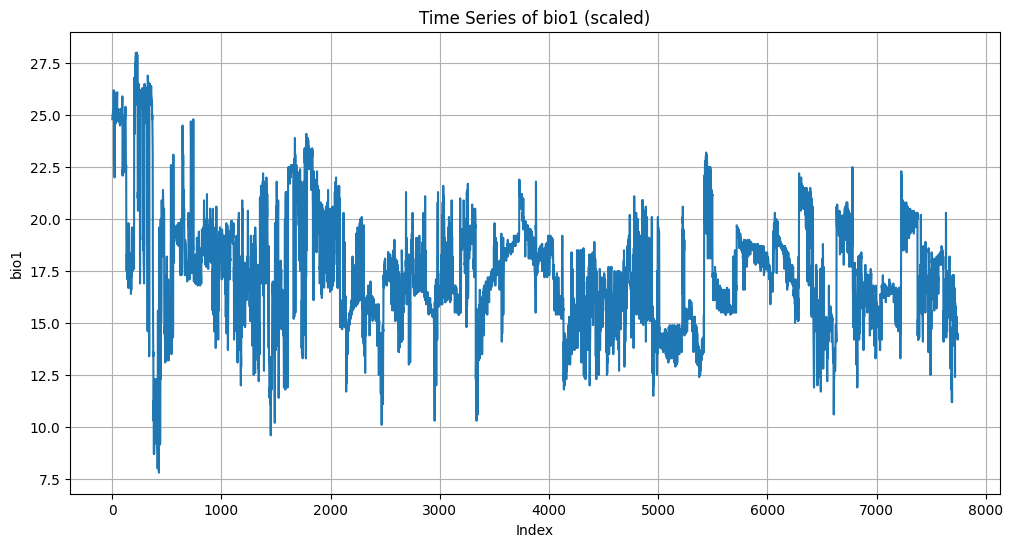

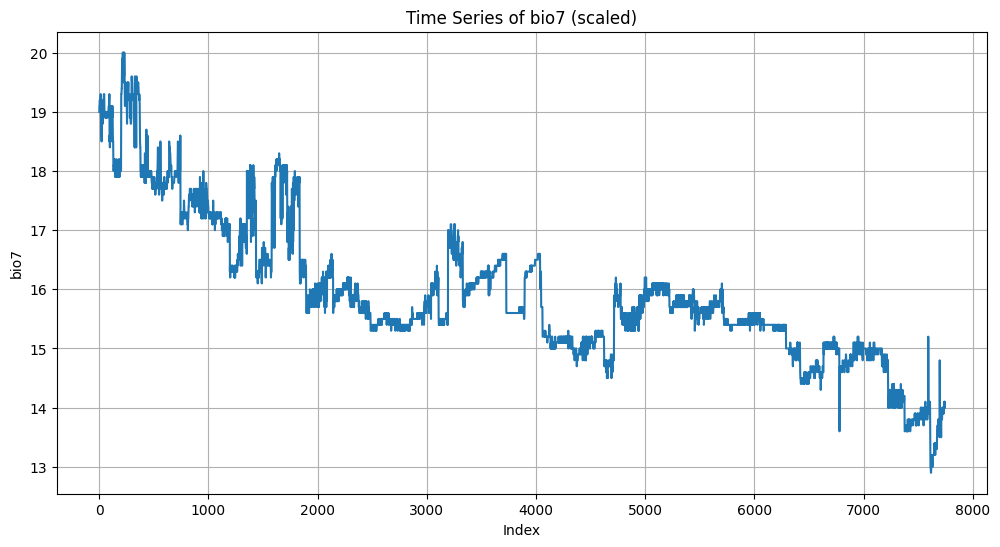

In [13]:
# Scale bio1 and bio7 if they exist
if 'bio1' in train_df.columns:
    train_df['bio1'] = train_df['bio1'] / 10
    plot_time_series(train_df, 'bio1', 'Time Series of bio1 (scaled)')

if 'bio7' in train_df.columns:
    train_df['bio7'] = train_df['bio7'] / 10
    plot_time_series(train_df, 'bio7', 'Time Series of bio7 (scaled)')

In [14]:
train_df.columns

Index(['site', 'PID', 'lon', 'lat', 'pH', 'alb', 'bio1', 'bio12', 'bio15',
       'bio7', 'bp', 'cec20', 'dows', 'ecec20', 'hp20', 'ls', 'lstd', 'lstn',
       'mb1', 'mb2', 'mb3', 'mb7', 'mdem', 'para', 'parv', 'ph20', 'slope',
       'snd20', 'soc20', 'tim', 'wp', 'xhp20', 'BulkDensity', 'N', 'P', 'K',
       'Ca', 'Mg', 'S', 'Fe', 'Mn', 'Zn', 'Cu', 'B'],
      dtype='object')

In [15]:
# Feature engineering functions
def create_lagged_features(dataframe, columns, lags=[1, 2, 7, 30]):
    """
    Create lagged features for specified columns.
    """
    df = dataframe.copy()
    for col in columns:
        if col in df.columns:
            for lag in lags:
                df[f'{col}_lag_{lag}steps'] = df[col].shift(lag)
    return df

def create_moving_averages(dataframe, columns, windows=[3, 7, 30]):
    """
    Create moving average features for specified columns.
    """
    df = dataframe.copy()
    for col in columns:
        if col in df.columns:
            for window in windows:
                df[f'{col}_MA_{window}steps'] = df[col].rolling(window=window).mean()
    return df

def perform_fourier_transform(dataframe, column_name, num_dominant_frequencies=3):
    """
    Performs Fourier Transform on a specified column and adds sine/cosine features.
    """
    if column_name not in dataframe.columns:
        print(f"Warning: Column '{column_name}' not found in dataframe")
        return dataframe
    
    df = dataframe.copy()
    series = df[column_name]
    N = len(series)

    # Perform DFT
    yf = fft(series.values)
    xf = fftfreq(N, d=1)

    # Get positive frequencies and amplitudes
    amplitudes = 2.0 / N * np.abs(yf[0:N // 2])
    positive_frequencies = xf[0:N // 2]

    # Identify dominant frequencies
    freq_df = pd.DataFrame({
        'Frequency': positive_frequencies,
        'Amplitude': amplitudes
    }).sort_values(by='Amplitude', ascending=False)

    dominant_frequencies = freq_df['Frequency'].head(num_dominant_frequencies).values

    # Create sine and cosine features
    t = np.arange(N)
    for i, freq in enumerate(dominant_frequencies):
        df[f'{column_name}_fourier_sin_{i + 1}'] = np.sin(2 * np.pi * freq * t)
        df[f'{column_name}_fourier_cos_{i + 1}'] = np.cos(2 * np.pi * freq * t)

    return df

def create_pca_features(dataframe, feature_columns, variance_threshold=0.95, prefix='PC'):
    """
    Create PCA features from specified columns.
    """
    # Filter existing columns
    existing_features = [col for col in feature_columns if col in dataframe.columns]
    
    if len(existing_features) == 0:
        print("No features found for PCA")
        return pd.DataFrame()
    
    X_features = dataframe[existing_features]
    
    # Handle missing values
    X_features = X_features.fillna(method='ffill').fillna(method='bfill')
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_features)
    
    # Apply PCA
    pca = PCA()
    pca.fit(X_scaled)
    
    # Find number of components for desired variance
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(cumulative_variance >= variance_threshold) + 1
    
    print(f"Number of components to retain {variance_threshold*100}% variance: {n_components}")
    
    # Final PCA
    pca_final = PCA(n_components=n_components)
    X_pca = pca_final.fit_transform(X_scaled)
    
    # Create DataFrame
    component_names = [f'{prefix}_{i+1}' for i in range(n_components)]
    pca_df = pd.DataFrame(data=X_pca, columns=component_names, index=dataframe.index)
    
    return pca_df, pca_final, scaler

In [16]:
# Process bio features if they exist
bio_columns = [col for col in ['bio1', 'bio7', 'bio12', 'bio15'] if col in train_df.columns]

if bio_columns:
    print("Processing bio features...")
    bio_df = create_lagged_features(train_df, bio_columns)
    bio_df = create_moving_averages(bio_df, bio_columns)
    
    for col in bio_columns:
        bio_df = perform_fourier_transform(bio_df, col)
    
    # Fill missing values
    bio_df = bio_df.fillna(method='bfill').fillna(method='ffill')
    
    # Create list of all bio-related features for PCA
    bio_features_for_pca = []
    for col in bio_columns:
        bio_features_for_pca.extend([
            col,
            f'{col}_lag_1steps', f'{col}_lag_2steps', f'{col}_lag_7steps', f'{col}_lag_30steps',
            f'{col}_MA_3steps', f'{col}_MA_7steps', f'{col}_MA_30steps',
            f'{col}_fourier_sin_1', f'{col}_fourier_cos_1',
            f'{col}_fourier_sin_2', f'{col}_fourier_cos_2',
            f'{col}_fourier_sin_3', f'{col}_fourier_cos_3'
        ])
    
    bio_pca_df, bio_pca_model, bio_scaler = create_pca_features(bio_df, bio_features_for_pca, prefix='bio_PC')
    print(f"Bio PCA shape: {bio_pca_df.shape}")


Processing bio features...
Number of components to retain 95.0% variance: 14
Bio PCA shape: (7744, 14)


In [17]:
# Remove xhp20 if it exists
if 'xhp20' in train_df.columns:
    train_df.drop('xhp20', axis=1, inplace=True)
    print("Dropped xhp20 column")


Dropped xhp20 column


In [18]:
# Process pH features if they exist
ph_columns = [col for col in ['hp20', 'ph20', 'pH'] if col in train_df.columns]

if ph_columns:
    print("Processing pH features...")
    ph_df = create_lagged_features(train_df, ph_columns)
    ph_df = create_moving_averages(ph_df, ph_columns)
    
    for col in ph_columns:
        ph_df = perform_fourier_transform(ph_df, col)
    
    # Fill missing values
    ph_df = ph_df.fillna(method='bfill').fillna(method='ffill')
    
    # Create list of all pH-related features for PCA
    ph_features_for_pca = []
    for col in ph_columns:
        ph_features_for_pca.extend([
            col,
            f'{col}_lag_1steps', f'{col}_lag_2steps', f'{col}_lag_7steps', f'{col}_lag_30steps',
            f'{col}_MA_3steps', f'{col}_MA_7steps', f'{col}_MA_30steps',
            f'{col}_fourier_sin_1', f'{col}_fourier_cos_1',
            f'{col}_fourier_sin_2', f'{col}_fourier_cos_2',
            f'{col}_fourier_sin_3', f'{col}_fourier_cos_3'
        ])
    
    ph_pca_df, ph_pca_model, ph_scaler = create_pca_features(ph_df, ph_features_for_pca, prefix='pH_PC')
    print(f"pH PCA shape: {ph_pca_df.shape}")


Processing pH features...
Number of components to retain 95.0% variance: 16
pH PCA shape: (7744, 16)


In [19]:
# Process mb features if they exist
mb_columns = [col for col in ['mb1', 'mb2', 'mb3', 'mb7'] if col in train_df.columns]

if mb_columns:
    print("Processing mb features...")
    mb_df = create_lagged_features(train_df, mb_columns)
    mb_df = create_moving_averages(mb_df, mb_columns)
    
    for col in mb_columns:
        mb_df = perform_fourier_transform(mb_df, col)
    
    # Fill missing values
    mb_df = mb_df.fillna(method='bfill').fillna(method='ffill')
    
    # Create list of all mb-related features for PCA
    mb_features_for_pca = []
    for col in mb_columns:
        mb_features_for_pca.extend([
            col,
            f'{col}_lag_1steps', f'{col}_lag_2steps', f'{col}_lag_7steps', f'{col}_lag_30steps',
            f'{col}_MA_3steps', f'{col}_MA_7steps', f'{col}_MA_30steps',
            f'{col}_fourier_sin_1', f'{col}_fourier_cos_1',
            f'{col}_fourier_sin_2', f'{col}_fourier_cos_2',
            f'{col}_fourier_sin_3', f'{col}_fourier_cos_3'
        ])
    
    mb_pca_df, mb_pca_model, mb_scaler = create_pca_features(mb_df, mb_features_for_pca, prefix='mb_PC')
    print(f"mb PCA shape: {mb_pca_df.shape}")

Processing mb features...
Number of components to retain 95.0% variance: 15
mb PCA shape: (7744, 15)


In [21]:
# Create final dataframe by combining original data with engineered features
final_df = train_df.copy()

# Add bio PCA features if they exist
if 'bio_pca_df' in locals() and not bio_pca_df.empty:
    final_df = pd.concat([final_df, bio_pca_df], axis=1)
    print(f"Added bio PCA features: {list(bio_pca_df.columns)}")

# Add pH PCA features if they exist
if 'ph_pca_df' in locals() and not ph_pca_df.empty:
    final_df = pd.concat([final_df, ph_pca_df], axis=1)
    print(f"Added pH PCA features: {list(ph_pca_df.columns)}")

# Add mb PCA features if they exist
if 'mb_pca_df' in locals() and not mb_pca_df.empty:
    final_df = pd.concat([final_df, mb_pca_df], axis=1)
    print(f"Added mb PCA features: {list(mb_pca_df.columns)}")

# Display final dataframe info
print(f"\nFinal dataframe shape: {final_df.shape}")
print(f"Original shape: {train_df.shape}")
print(f"New features added: {final_df.shape[1] - train_df.shape[1]}")

Added bio PCA features: ['bio_PC_1', 'bio_PC_2', 'bio_PC_3', 'bio_PC_4', 'bio_PC_5', 'bio_PC_6', 'bio_PC_7', 'bio_PC_8', 'bio_PC_9', 'bio_PC_10', 'bio_PC_11', 'bio_PC_12', 'bio_PC_13', 'bio_PC_14']
Added pH PCA features: ['pH_PC_1', 'pH_PC_2', 'pH_PC_3', 'pH_PC_4', 'pH_PC_5', 'pH_PC_6', 'pH_PC_7', 'pH_PC_8', 'pH_PC_9', 'pH_PC_10', 'pH_PC_11', 'pH_PC_12', 'pH_PC_13', 'pH_PC_14', 'pH_PC_15', 'pH_PC_16']
Added mb PCA features: ['mb_PC_1', 'mb_PC_2', 'mb_PC_3', 'mb_PC_4', 'mb_PC_5', 'mb_PC_6', 'mb_PC_7', 'mb_PC_8', 'mb_PC_9', 'mb_PC_10', 'mb_PC_11', 'mb_PC_12', 'mb_PC_13', 'mb_PC_14', 'mb_PC_15']

Final dataframe shape: (7744, 88)
Original shape: (7744, 43)
New features added: 45


In [29]:
# get the features with vif > 100
high_vif_features = vif[vif['VIF Factor'] > 100]['features'].tolist()
high_vif_features

['lon',
 'lat',
 'pH',
 'alb',
 'bio1',
 'bio7',
 'cec20',
 'lstd',
 'lstn',
 'mb1',
 'mb2',
 'mb3',
 'mb7',
 'mdem',
 'ph20',
 'BulkDensity']

In [30]:
final_df = final_df.drop(columns=high_vif_features, errors='ignore')
final_df.shape

(7744, 72)

In [32]:
final_df = final_df.drop(columns=['site', 'PID'], errors='ignore')


In [33]:
def scale_features(train_df, target_variables=None, exclude_columns=None):
    """
    Scale features using StandardScaler, excluding target variables and specified columns.
    
    Parameters:
    -----------
    train_df : pd.DataFrame
        Training dataframe
    target_variables : list, optional
        List of target variable column names to exclude from scaling
    exclude_columns : list, optional
        Additional columns to exclude from scaling
    
    Returns:
    --------
    train_scaled : pd.DataFrame
        Scaled training dataframe
    scaler : StandardScaler
        Fitted scaler object for future use
    """
    # Initialize lists
    if target_variables is None:
        target_variables = []
    if exclude_columns is None:
        exclude_columns = []
    
    # Combine all columns to exclude
    all_exclude_columns = list(set(target_variables + exclude_columns))
    
    # Identify numerical columns to scale
    numerical_columns = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    columns_to_scale = [col for col in numerical_columns if col not in all_exclude_columns]
    
    print(f"Columns to scale: {len(columns_to_scale)}")
    print(f"Excluded columns: {all_exclude_columns}")
    
    # Initialize and fit scaler on training data
    scaler = StandardScaler()
    
    # Create a copy of the dataframe
    train_scaled = train_df.copy()
    
    if columns_to_scale:
        # Fit and transform training data
        train_scaled[columns_to_scale] = scaler.fit_transform(train_df[columns_to_scale])
        print(f"Successfully scaled {len(columns_to_scale)} features")
    else:
        print("No columns found to scale")
    
    return train_scaled, scaler

# target variables 
target_vars = ['N', 'P', 'K', 'Zn', 'S', 'Ca', 'Mg', 'B', 'Cu', 'Fe', 'Mn']

# Scale the final dataframe
final_df_scaled, feature_scaler = scale_features(
    train_df=final_df,
    target_variables=target_vars
)

print(f"\nScaled training data shape: {final_df_scaled.shape}")


Columns to scale: 59
Excluded columns: ['B', 'S', 'Cu', 'Mn', 'Ca', 'Fe', 'K', 'Zn', 'P', 'Mg', 'N']
Successfully scaled 59 features

Scaled training data shape: (7744, 70)


In [38]:
def train_individual_models(X_train, X_test, y_train, y_test, target_variables, models_dict, cv_folds=5):
    """
    Train and evaluate individual models for each target variable separately.
    
    Parameters:
    -----------
    X_train, X_test : pd.DataFrame or np.array
        Feature matrices for training and testing
    y_train, y_test : pd.DataFrame
        Target matrices for training and testing
    target_variables : list
        List of target variable names
    models_dict : dict
        Dictionary of model names and their instances
    cv_folds : int
        Number of cross-validation folds
    
    Returns:
    --------
    results : dict
        Nested dictionary with results for each target and model
    predictions : dict
        Dictionary with predictions for each target and model
    best_models : dict
        Dictionary with best model for each target
    """
    
    results = {}
    predictions = {}
    best_models = {}
    
    print("Training individual models for each target...")
    print("=" * 60)
    
    for target in target_variables:
        if target not in y_train.columns:
            print(f"Warning: {target} not found in training data")
            continue
            
        print(f"\nTraining models for target: {target}")
        print("-" * 40)
        
        results[target] = {}
        predictions[target] = {}
        target_scores = {}
        
        y_train_target = y_train[target]
        y_test_target = y_test[target] if target in y_test.columns else None
        
        for model_name, model in models_dict.items():
            try:
                # Cross-validation on training data
                cv_scores = cross_val_score(model, X_train, y_train_target, 
                                          cv=cv_folds, scoring='r2')
                
                # Fit the model
                model.fit(X_train, y_train_target)
                
                # Predictions
                y_train_pred = model.predict(X_train)
                y_test_pred = model.predict(X_test) if X_test is not None else None
                
                # Store predictions
                predictions[target][model_name] = {
                    'train_pred': y_train_pred,
                    'test_pred': y_test_pred
                }
                
                # Calculate metrics
                train_r2 = r2_score(y_train_target, y_train_pred)
                train_rmse = np.sqrt(mean_squared_error(y_train_target, y_train_pred))
                train_mae = mean_absolute_error(y_train_target, y_train_pred)
                
                # Test metrics (if test data available)
                test_r2 = r2_score(y_test_target, y_test_pred) if y_test_target is not None else None
                test_rmse = np.sqrt(mean_squared_error(y_test_target, y_test_pred)) if y_test_target is not None else None
                test_mae = mean_absolute_error(y_test_target, y_test_pred) if y_test_target is not None else None
                
                # Store results
                results[target][model_name] = {
                    'cv_r2_mean': cv_scores.mean(),
                    'cv_r2_std': cv_scores.std(),
                    'train_r2': train_r2,
                    'train_rmse': train_rmse,
                    'train_mae': train_mae,
                    'test_r2': test_r2,
                    'test_rmse': test_rmse,
                    'test_mae': test_mae
                }
                
                target_scores[model_name] = cv_scores.mean()
                
                # Fixed print statement with proper None handling
                test_r2_str = f"{test_r2:.4f}" if test_r2 is not None else "N/A"
                test_rmse_str = f"{test_rmse:.4f}" if test_rmse is not None else "N/A"
                test_mae_str = f"{test_mae:.4f}" if test_mae is not None else "N/A"
                
                print(f"{model_name:20} | CV R²: {cv_scores.mean():.4f}±{cv_scores.std():.4f} | "
                      f"Train R²: {train_r2:.4f} | Train RMSE: {train_rmse:.4f} | Train MAE: {train_mae:.4f} | "
                      f"Test R²: {test_r2_str} | Test RMSE: {test_rmse_str} | Test MAE: {test_mae_str}")
                
            except Exception as e:
                print(f"Error training {model_name} for {target}: {e}")
                continue
        
        # Find best model for this target
        if target_scores:
            best_model_name = max(target_scores, key=target_scores.get)
            best_models[target] = {
                'model_name': best_model_name,
                'model': models_dict[best_model_name],
                'cv_score': target_scores[best_model_name]
            }
            print(f"\nBest model for {target}: {best_model_name} (CV R²: {target_scores[best_model_name]:.4f})")
    
    return results, predictions, best_models


# Also fix the display function
def display_individual_model_results(results):
    """
    Display results for individual models in a readable format.
    """
    for target, model_results in results.items():
        print(f"\nResults for target: {target}")
        print("-" * 40)
        for model_name, metrics in model_results.items():
            # Handle None values properly
            test_r2_str = f"{metrics['test_r2']:.4f}" if metrics['test_r2'] is not None else "N/A"
            test_rmse_str = f"{metrics['test_rmse']:.4f}" if metrics['test_rmse'] is not None else "N/A"
            test_mae_str = f"{metrics['test_mae']:.4f}" if metrics['test_mae'] is not None else "N/A"
            
            print(f"{model_name:20} | CV R²: {metrics['cv_r2_mean']:.4f}±{metrics['cv_r2_std']:.4f} | "
                  f"Train R²: {metrics['train_r2']:.4f} | Train RMSE: {metrics['train_rmse']:.4f} | "
                  f"Train MAE: {metrics['train_mae']:.4f} | "
                  f"Test R²: {test_r2_str} | "
                  f"Test RMSE: {test_rmse_str} | "
                  f"Test MAE: {test_mae_str}")
    print("\n" + "=" * 60)

In [39]:
target_vars = ['N', 'P', 'K', 'Zn', 'S', 'Ca', 'Mg', 'B', 'Cu', 'Fe', 'Mn']
X = final_df_scaled.drop(columns=target_vars, errors='ignore')
y = final_df_scaled[target_vars]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)
# Define models
models_dict = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'ElasticNet Regression': ElasticNet(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=17),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=17),
    'Support Vector Regression': SVR(kernel='rbf')
}
# Train individual models
results, predictions, best_models = train_individual_models(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    target_variables=target_vars,
    models_dict=models_dict,
    cv_folds=5
)
# Display results
display_individual_model_results(results)       
# Display best models
print("\nBest Models for Each Target Variable:")
for target, best_model_info in best_models.items():
    print(f"{target}: {best_model_info['model_name']} (CV R²: {best_model_info['cv_score']:.4f})")


Training individual models for each target...

Training models for target: N
----------------------------------------
Linear Regression    | CV R²: 0.4404±0.0181 | Train R²: 0.4532 | Train RMSE: 557.0743 | Train MAE: 409.5332 | Test R²: 0.4256 | Test RMSE: 550.8116 | Test MAE: 414.1373
Ridge Regression     | CV R²: 0.4389±0.0181 | Train R²: 0.4506 | Train RMSE: 558.3657 | Train MAE: 410.3430 | Test R²: 0.4258 | Test RMSE: 550.7273 | Test MAE: 415.0376
Lasso Regression     | CV R²: 0.4364±0.0178 | Train R²: 0.4469 | Train RMSE: 560.2296 | Train MAE: 411.5449 | Test R²: 0.4235 | Test RMSE: 551.8023 | Test MAE: 414.5803
ElasticNet Regression | CV R²: 0.4146±0.0147 | Train R²: 0.4210 | Train RMSE: 573.2156 | Train MAE: 421.8981 | Test R²: 0.4045 | Test RMSE: 560.8553 | Test MAE: 420.3885
Random Forest        | CV R²: 0.5565±0.0193 | Train R²: 0.9377 | Train RMSE: 188.0120 | Train MAE: 134.3527 | Test R²: 0.5385 | Test RMSE: 493.7072 | Test MAE: 363.5121
Gradient Boosting    | CV R²: 0.5097

In [ ]:
def train_multioutput_models(X_train, X_test, y_train, y_test, target_variables, models_dict, cv_folds=5):
    """
    Train and evaluate multi-output regression models.
    
    Parameters:
    -----------
    X_train, X_test : pd.DataFrame or np.array
        Feature matrices for training and testing
    y_train, y_test : pd.DataFrame
        Target matrices for training and testing
    target_variables : list
        List of target variable names
    models_dict : dict
        Dictionary of model names and their instances
    cv_folds : int
        Number of cross-validation folds
    
    Returns:
    --------
    results : dict
        Dictionary with results for each model
    predictions : dict
        Dictionary with predictions for each model
    best_model : dict
        Dictionary with information about the best performing model
    """
    
    results = {}
    predictions = {}
    model_scores = {}
    
    print("\nTraining multi-output regression models...")
    print("=" * 60)
    
    # Filter target variables that exist in training data
    available_targets = [target for target in target_variables if target in y_train.columns]
    y_train_multi = y_train[available_targets]
    y_test_multi = y_test[available_targets] if y_test is not None else None
    
    print(f"Training for targets: {available_targets}")
    print("-" * 40)
    
    for model_name, base_model in models_dict.items():
        try:
            # Create multi-output wrapper
            multi_model = MultiOutputRegressor(base_model)
            
            # Cross-validation (using mean R² across all targets)
            cv_scores = cross_val_score(multi_model, X_train, y_train_multi, 
                                      cv=cv_folds, scoring='r2')
            
            # Fit the model
            multi_model.fit(X_train, y_train_multi)
            
            # Predictions
            y_train_pred = multi_model.predict(X_train)
            y_test_pred = multi_model.predict(X_test) if X_test is not None else None
            
            # Store predictions
            predictions[model_name] = {
                'train_pred': pd.DataFrame(y_train_pred, columns=available_targets, index=y_train_multi.index),
                'test_pred': pd.DataFrame(y_test_pred, columns=available_targets, index=y_test_multi.index) if y_test_pred is not None else None
            }
            
            # Calculate metrics for each target
            target_metrics = {}
            overall_train_r2 = []
            overall_test_r2 = []
            
            for i, target in enumerate(available_targets):
                # Training metrics
                train_r2 = r2_score(y_train_multi[target], y_train_pred[:, i])
                train_rmse = np.sqrt(mean_squared_error(y_train_multi[target], y_train_pred[:, i]))
                train_mae = mean_absolute_error(y_train_multi[target], y_train_pred[:, i])
                
                overall_train_r2.append(train_r2)
                
                # Test metrics
                test_r2 = None
                test_rmse = None
                test_mae = None
                
                if y_test_multi is not None:
                    test_r2 = r2_score(y_test_multi[target], y_test_pred[:, i])
                    test_rmse = np.sqrt(mean_squared_error(y_test_multi[target], y_test_pred[:, i]))
                    test_mae = mean_absolute_error(y_test_multi[target], y_test_pred[:, i])
                    overall_test_r2.append(test_r2)
                
                target_metrics[target] = {
                    'train_r2': train_r2,
                    'train_rmse': train_rmse,
                    'train_mae': train_mae,
                    'test_r2': test_r2,
                    'test_rmse': test_rmse,
                    'test_mae': test_mae
                }
            
            # Store overall results
            results[model_name] = {
                'cv_r2_mean': cv_scores.mean(),
                'cv_r2_std': cv_scores.std(),
                'overall_train_r2': np.mean(overall_train_r2),
                'overall_test_r2': np.mean(overall_test_r2) if overall_test_r2 else None,
                'target_metrics': target_metrics,
                'model': multi_model
            }
            
            model_scores[model_name] = cv_scores.mean()
            
            # Print results
            print(f"{model_name:20} | CV R²: {cv_scores.mean():.4f}±{cv_scores.std():.4f} | "
                  f"Train R²: {np.mean(overall_train_r2):.4f} | "
                  f"Test R²: {np.mean(overall_test_r2):.4f if overall_test_r2 else 'N/A'}")
            
        except Exception as e:
            print(f"Error training {model_name}: {e}")
            continue
    
    # Find best model
    best_model = None
    if model_scores:
        best_model_name = max(model_scores, key=model_scores.get)
        best_model = {
            'model_name': best_model_name,
            'model': results[best_model_name]['model'],
            'cv_score': model_scores[best_model_name],
            'results': results[best_model_name]
        }
        print(f"\nBest multi-output model: {best_model_name} (CV R²: {model_scores[best_model_name]:.4f})")
    
    return results, predictions, best_model

In [ ]:
# Train multi-output models
multioutput_results, multioutput_predictions, best_multioutput = train_multioutput_models(
    X_train, X_test, y_train, y_test, target_vars, models
)
"""